객체 인지하는 네모박스를 만들어보자!

 torchvision.utils.draw_bounding_boxes 
 torchvision.utils.draw_bounding_boxes를 이용해 바운딩 박스를 처리하는 방법은 다음과 같습니다.

requests.get(url)을 사용하여 이미지를 다운로드한 후, 
BytesIO(response.content)를 통해 이미지 데이터를 PIL.Image 객체로 변환
pil_to_tensor를 사용하여 이미지를 텐서로 변환
ConvertImageDtype을 사용해 텐서를 torch.uint8 데이터 타입으로 변환하여 바운딩 박스 시각화
draw_bounding_boxes 함수를 사용해 바운딩 박스를 이미지에 그리며, 라벨도 함께 표시


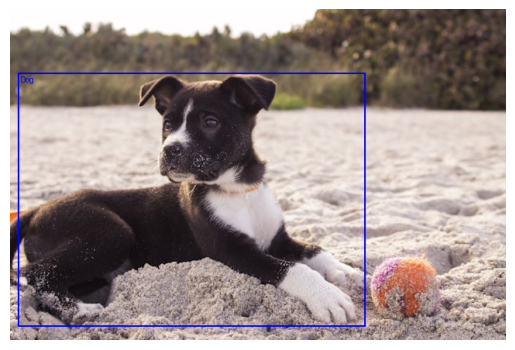

In [1]:
import torch
from torchvision.utils import draw_bounding_boxes
import matplotlib.pyplot as plt
import numpy as np
import requests
from io import BytesIO
from PIL import Image
from torchvision.transforms.functional import pil_to_tensor
from torchvision.transforms.v2 import ConvertImageDtype

import os
os.environ['KMP_DUPLICATE_LIB_OK']='True'

# URL에서 이미지 다운로드
url = "https://images.unsplash.com/photo-1424709746721-b8fd0ff52499?w=640"
response = requests.get(url)

# 이미지 데이터를 PIL Image 객체로 변환
image = Image.open(BytesIO(response.content))

# 이미지를 텐서로 변환 (C, H, W 형태로 변환)
image_tensor = pil_to_tensor(image)

# 텐서의 데이터 타입을 uint8로 변환 (바운딩 박스 시각화를 위해 필요)
convert_dtype = ConvertImageDtype(torch.uint8)
image_tensor = convert_dtype(image_tensor)

# 바운딩 박스 좌표와 라벨 정의 (예시: 'Dog' 클래스)
boxes = torch.tensor([[10, 82, 458, 409]])  # 바운딩 박스 좌표 (x_min, y_min, x_max, y_max)
labels = ["Dog"]  # 해당 바운딩 박스의 라벨

# 바운딩 박스와 라벨 그리기 (파란색 박스, 선 굵기 2)
boxed_image_with_labels = draw_bounding_boxes(image_tensor, boxes, labels=labels, colors="blue", width=2)

# 이미지 시각화 (채널 순서를 (H, W, C)로 변경 후 표시)
plt.imshow(np.transpose(boxed_image_with_labels.numpy(), (1, 2, 0)))
plt.axis("off")  # 축 숨기기
plt.show()


PIL.ImageDraw

PIL.ImageDraw는 이미지 위에 직접 바운딩 박스를 그릴 수 있는 기능을 제공

requests.get(url)을 사용해 이미지를 다운로드한 후, 
BytesIO(response.content)를 통해 이미지 데이터를 PIL.Image 객체로 변환
pil_to_tensor를 사용해 이미지를 텐서로 변환할 수 있지만, 변환된 텐서를 사용하지 않더라도 이미지를 시각화하거나 저장하는 데 사용할 수 있음
ImageDraw.Draw(image)를 사용해 이미지를 그리기 위한 객체를 생성
draw.rectangle을 사용해 바운딩 박스를 그림.
이때 outline 매개변수를 사용해 박스의 색상을 지정하고, width 매개변수를 사용해 두께를 지정.
draw.text를 사용해 라벨을 추가
라벨의 위치는 바운딩 박스 위에 설정해 쉽게 식별할 수 있도록 함.
matplotlib.pyplot을 사용해 결과 이미지를 표시합니다

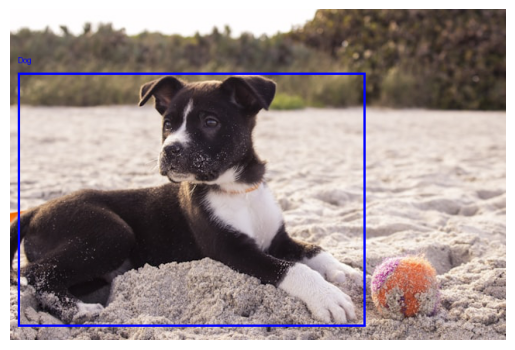

In [2]:
from PIL import Image, ImageDraw
from torchvision.transforms.functional import pil_to_tensor
import matplotlib.pyplot as plt
import requests
from io import BytesIO

import os
os.environ['KMP_DUPLICATE_LIB_OK']='True'

# URL에서 이미지 다운로드
url = "https://images.unsplash.com/photo-1424709746721-b8fd0ff52499?w=640"
response = requests.get(url)

# 이미지 데이터를 PIL Image 객체로 변환
image = Image.open(BytesIO(response.content))

# 이미지를 텐서로 변환 (추후 사용 가능, 현재 시각화에는 사용되지 않음)
image_tensor = pil_to_tensor(image)

# 이미지를 그리기 위한 PIL ImageDraw 객체 생성
draw = ImageDraw.Draw(image)

# 바운딩 박스 그리기 (좌상단 좌표: 10, 82, 우하단 좌표: 458, 409)
draw.rectangle([10, 82, 458, 409], outline="blue", width=3)  # 파란색 테두리, 두께 3

# 바운딩 박스 위에 라벨 텍스트 추가 (텍스트 위치 조정)
draw.text((10, 60), "Dog", fill="blue")  # 파란색 텍스트

# 결과 이미지 표시
plt.imshow(image)  # 이미지를 matplotlib을 통해 화면에 출력
plt.axis("off")  # 축 숨기기
plt.show()


matplotli
torchvision의 기능을 사용하지 않고 직접 바운딩 박스를 그리는 방식, 세부적인 제어가 가능.

requests.get(url)을 사용해 이미지를 다운로드한 후,
BytesIO(response.content)를 통해 이미지 데이터를 PIL.Image 객체로 변환.
pil_to_tensor를 사용해 이미지를 텐서로 변환한 후, permute를 이용해 차원의 순서를 변경하여 numpy 배열로 변환.
matplotlib.pyplot.subplots()를 이용해 이미지를 표시할 축을 생성.
patches.Rectangle을 사용해 바운딩 박스를 생성하고, ax.add_patch(rect)를 통해 이미지를 표시할 축에 추가.
plt.text를 사용해 바운딩 박스 위에 라벨을 추가.
마지막으로 plt.show()를 이용해 이미지를 시각화.

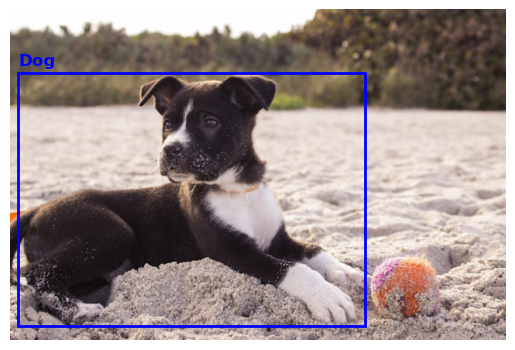

In [3]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import requests
from io import BytesIO
from PIL import Image
from torchvision.transforms.functional import pil_to_tensor

import os
os.environ['KMP_DUPLICATE_LIB_OK']='True'

# URL에서 이미지 다운로드
url = "https://images.unsplash.com/photo-1424709746721-b8fd0ff52499?w=640"
response = requests.get(url)

# 이미지 데이터를 PIL Image 객체로 변환
image = Image.open(BytesIO(response.content))

# 이미지를 텐서로 변환
image_tensor = pil_to_tensor(image)

# 텐서를 numpy 배열로 변환 (HWC 형태로 변환)
np_image = image_tensor.permute(1, 2, 0).numpy()

# 이미지와 바운딩 박스 시각화를 위한 설정
fig, ax = plt.subplots(1)

# 이미지를 축에 표시
ax.imshow(np_image)

# 바운딩 박스 그리기 (x_min, y_min, 너비, 높이)
x_min, y_min, x_max, y_max = 10, 82, 458, 409
rect = patches.Rectangle((x_min, y_min), x_max - x_min, y_max - y_min, linewidth=2, edgecolor="blue", facecolor="none")

# 바운딩 박스를 이미지에 추가
ax.add_patch(rect)

# 바운딩 박스 위에 라벨 추가 (x_min, y_min 위치에 "Dog" 텍스트 추가)
plt.text(x_min, y_min - 10, "Dog", color="blue", fontsize=12, weight="bold")

# 이미지 표시 (축 숨기기)
plt.axis("off")
plt.show()


OpenCV
이미지 처리에 널리 사용되는 OpenCV 라이브러리를 활용해 바운딩 박스를 그리고 라벨을 표시하는 방식.

requests.get(url)을 사용해 이미지를 다운로드한 후,
BytesIO(response.content)를 통해 이미지 데이터를 PIL.Image 객체로 변환.
pil_to_tensor를 사용해 이미지를 텐서로 변환한 후,
permute를 이용해 차원의 순서를 변경하고 numpy 배열로 변환.
cv2.cvtColor를 사용해 RGB 형식을 BGR 형식으로 변환.(OpenCV는 기본적으로 BGR 형식을 사용하기 때문)
cv2.rectangle을 사용해 바운딩 박스를 그리고, cv2.putText를 사용해 바운딩 박스 위에 라벨을 추가.
이미지를 다시 BGR 형식에서 RGB 형식으로 변환한 후, matplotlib.pyplot을 사용해 이미지를 표시.

먼저 opencv를 설치해주자.

In [5]:
! pip install opencv-python

   ---------------------------------------- 0.0/39.0 MB ? eta -:--:--
   ---------------- ----------------------- 16.5/39.0 MB 90.4 MB/s eta 0:00:01
   --------------------------------- ------ 33.0/39.0 MB 85.5 MB/s eta 0:00:01
   ---------------------------------------  38.8/39.0 MB 68.1 MB/s eta 0:00:01
   ---------------------------------------- 39.0/39.0 MB 55.6 MB/s eta 0:00:00


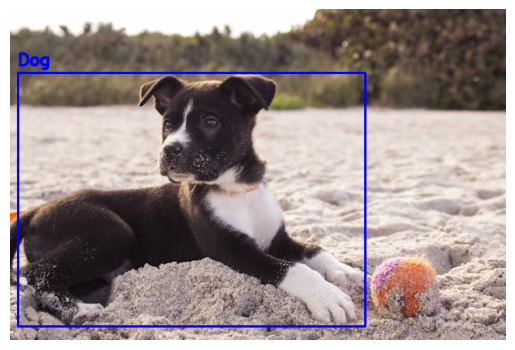

In [6]:
import cv2
import numpy as np
import requests
from io import BytesIO
from PIL import Image
from torchvision.transforms.functional import pil_to_tensor
import matplotlib.pyplot as plt

import os
os.environ['KMP_DUPLICATE_LIB_OK']='True'

# URL에서 이미지 다운로드
url = "https://images.unsplash.com/photo-1424709746721-b8fd0ff52499?w=640"
response = requests.get(url)

# 이미지 데이터를 PIL Image 객체로 변환
image = Image.open(BytesIO(response.content))

# 이미지를 텐서로 변환하고 numpy 배열로 변환 (HWC 형태로 변환)
image_tensor = pil_to_tensor(image)
np_image = image_tensor.permute(1, 2, 0).numpy().astype(np.uint8)

# RGB 이미지를 BGR 형식으로 변환 (OpenCV는 BGR을 사용)
np_image_bgr = cv2.cvtColor(np_image, cv2.COLOR_RGB2BGR)

# 바운딩 박스 좌표 (x_min, y_min, x_max, y_max)
x_min, y_min, x_max, y_max = 10, 82, 458, 409

# 바운딩 박스 그리기 (파란색, 두께 2)
color = (255, 0, 0)  # BGR 형식
thickness = 2
np_image_bgr = cv2.rectangle(np_image_bgr, (x_min, y_min), (x_max, y_max), color, thickness)

# 바운딩 박스 위에 라벨 텍스트 추가 ("Dog" 텍스트 추가)
font = cv2.FONT_HERSHEY_SIMPLEX
font_scale = 0.7
font_thickness = 2
np_image_bgr = cv2.putText(np_image_bgr, "Dog", (x_min, y_min - 10), font, font_scale, color, font_thickness, cv2.LINE_AA)

# BGR 이미지를 다시 RGB 형식으로 변환
np_image_rgb = cv2.cvtColor(np_image_bgr, cv2.COLOR_BGR2RGB)

# matplotlib을 사용해 이미지 표시 (축 숨기기)
plt.imshow(np_image_rgb)
plt.axis("off")
plt.show()
